## Brain Tumor Detection


Problem Statement: Brain tumors are a serious health problem that can be difficult to detect early. Early detection is crucial for successful treatment, but current methods are often time-consuming and inaccurate.​
​


Motivation: Our project aims to develop a deep learning model that can accurately detect brain tumors from MRI images. This model could help doctors diagnose brain tumors earlier and more accurately, leading to better patient outcomes.​
​


Objective: The objective of this project is to develop a deep learning model that can accurately classify brain tumor images with an accuracy of at least 90%.​


### Importing Libraries

In [3]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import random
from collections import Counter
import kagglehub
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
import shutil
import tensorflow as tf
import numpy as np
import requests
from io import BytesIO
from tensorflow.keras.preprocessing import image as keras_image
from tensorflow.keras.applications import ResNet50

### Downloading Data

In [4]:
# Download latest version to /kaggle/input
path = kagglehub.dataset_download("tombackert/brain-tumor-mri-data")

print("Path to dataset files:", path)

Path to dataset files: /Users/ayush/.cache/kagglehub/datasets/tombackert/brain-tumor-mri-data/versions/1


### EDA - Exploratory Data Analysis

In [5]:
# Dataset path
dataset_path = '/Users/ayush/Desktop/Sem 2/ProjectInML1/brain-tumor-mri-dataset'

# Subfolder (class) names
categories = os.listdir(dataset_path)
print("Classes in the dataset:", categories)

Classes in the dataset: ['pituitary', 'notumor', 'glioma', 'meningioma']


Number of images in each class: {'pituitary': 1757, 'notumor': 2000, 'glioma': 1621, 'meningioma': 1775} 




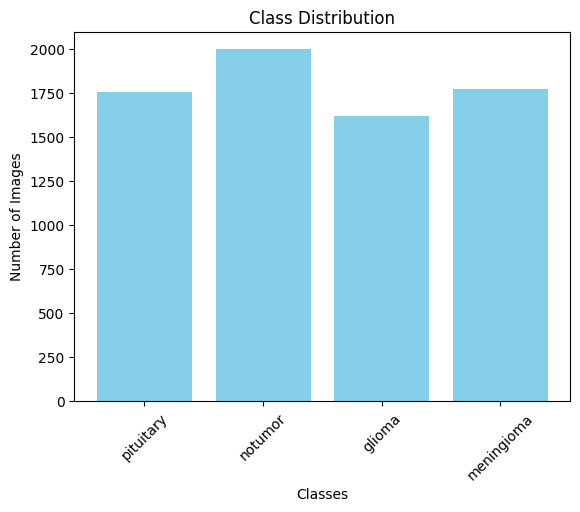

In [6]:
# Count number of images in each class
image_counts = {
    category: len(os.listdir(os.path.join(dataset_path, category)))
    for category in categories
    if os.path.isdir(os.path.join(dataset_path, category))  # Check if it's a directory
}

print("Number of images in each class:", image_counts, "\n\n")

# Plot class distribution
plt.bar(image_counts.keys(), image_counts.values(), color='skyblue')
plt.title('Class Distribution')
plt.xlabel('Classes')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.show()

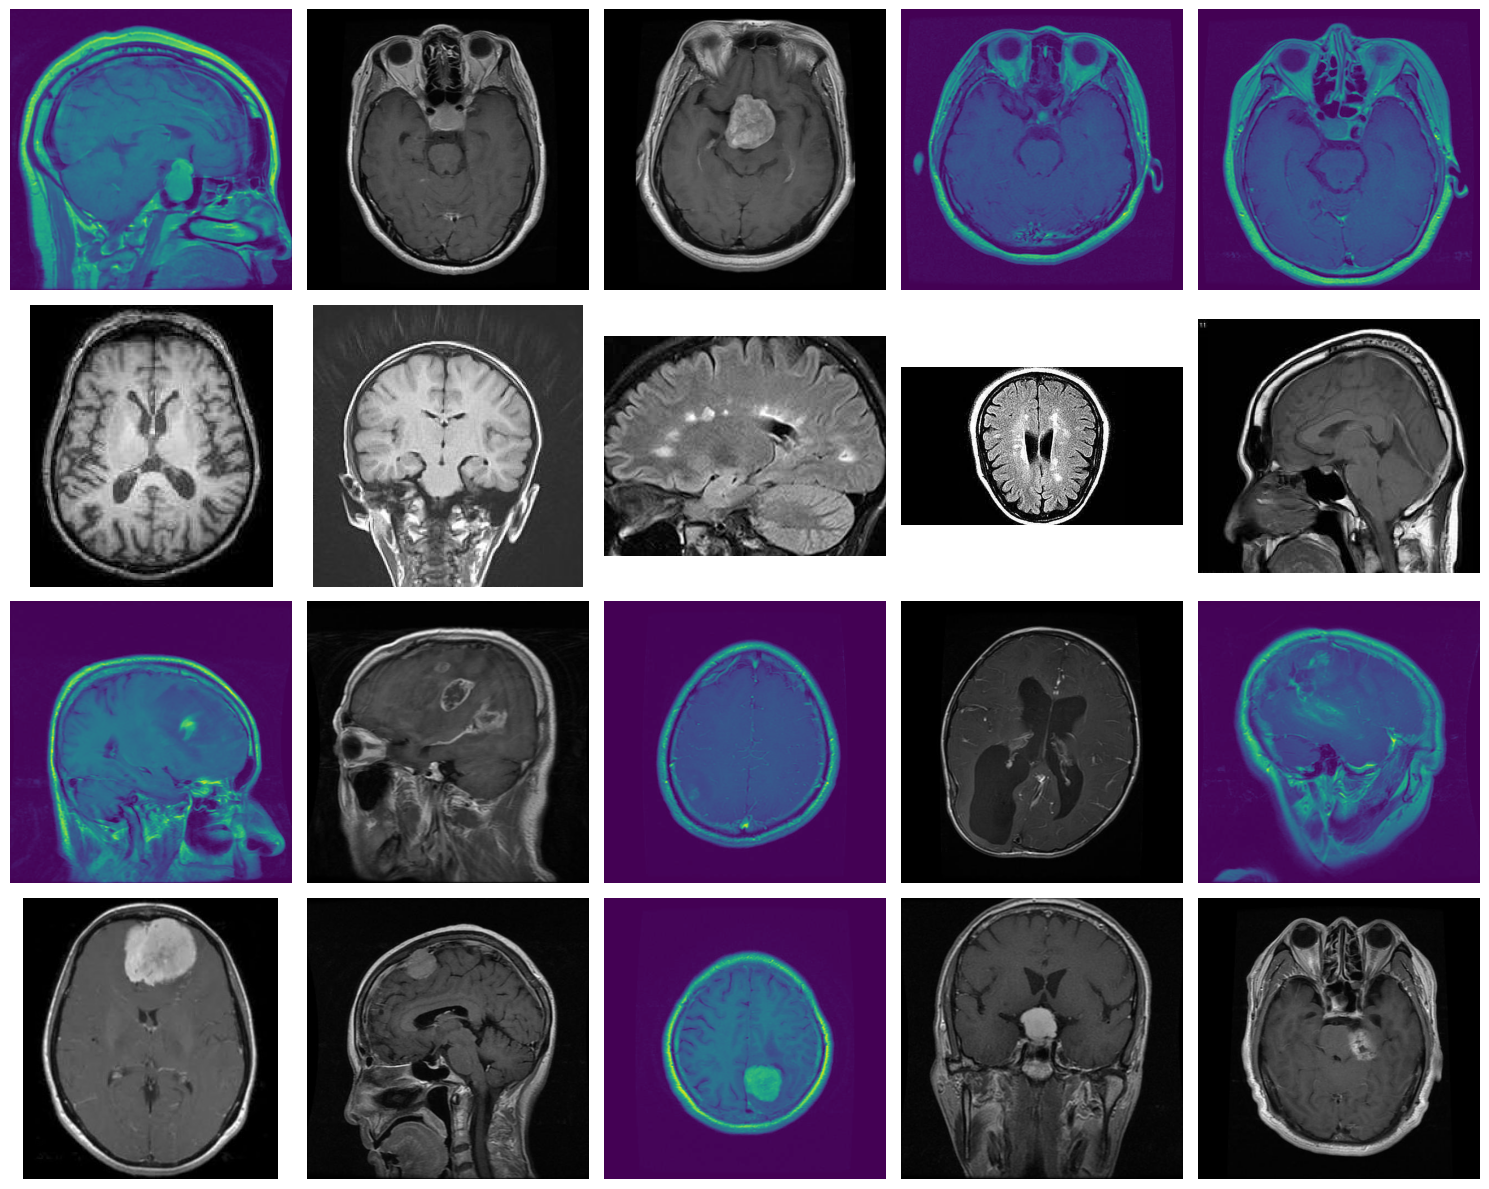

In [7]:
# Display 5 random images from each category
def display_sample_images(dataset_path, categories, num_samples=5):
    plt.figure(figsize=(15, len(categories) * 3))
    for i, category in enumerate(categories):
        category_path = os.path.join(dataset_path, category)
        if not os.path.isdir(category_path):  # Skip non-directory entries
            continue
        images = random.sample(os.listdir(category_path), num_samples)
        for j, img_name in enumerate(images):
            img_path = os.path.join(category_path, img_name)
            img = Image.open(img_path)
            plt.subplot(len(categories), num_samples, i * num_samples + j + 1)
            plt.imshow(img)
            plt.axis('off')
            if j == 0:
                plt.ylabel(category, fontsize=14)
    plt.tight_layout()
    plt.show()

# Call the function
categories = [cat for cat in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, cat))]
display_sample_images(dataset_path, categories, num_samples=5)

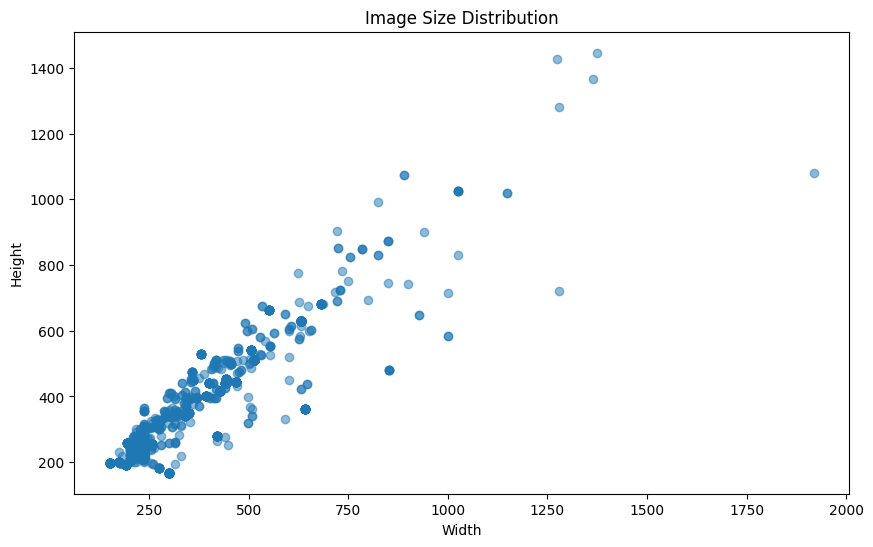

Most common image size: ((512, 512), 4859)


In [8]:
# Analyze image sizes
image_sizes = []
for category in categories:
    category_path = os.path.join(dataset_path, category)
    for img_name in os.listdir(category_path):
        img_path = os.path.join(category_path, img_name)
        with Image.open(img_path) as img:
            image_sizes.append(img.size)

# Plot distribution of image sizes
widths, heights = zip(*image_sizes)
plt.figure(figsize=(10, 6))
plt.scatter(widths, heights, alpha=0.5)
plt.title('Image Size Distribution')
plt.xlabel('Width')
plt.ylabel('Height')
plt.show()

print(f"Most common image size: {Counter(image_sizes).most_common(1)[0]}")

### Data Preprocessing

In [9]:
# Check for duplicate images
image_hashes = set()
duplicate_count = 0

for category in categories:
    category_path = os.path.join(dataset_path, category)
    for img_name in os.listdir(category_path):
        img_path = os.path.join(category_path, img_name)
        with Image.open(img_path) as img:
            img_hash = hash(img.tobytes())  # Hash of image data
            if img_hash in image_hashes:
                duplicate_count += 1
            else:
                image_hashes.add(img_hash)

print(f"Number of duplicate images: {duplicate_count}")

Number of duplicate images: 556


In [10]:
# Path to dataset
dataset_path = '/Users/ayush/Desktop/Sem 2/ProjectInML1/brain-tumor-mri-dataset'

# Identify and remove duplicates
image_hashes = set()
duplicate_count = 0

for category in os.listdir(dataset_path):
    category_path = os.path.join(dataset_path, category)
    if not os.path.isdir(category_path):  # Skip non-directories
        continue
    for img_name in os.listdir(category_path):
        img_path = os.path.join(category_path, img_name)
        try:
            with Image.open(img_path) as img:
                img_hash = hash(img.tobytes())  # Generate hash of the image
                if img_hash in image_hashes:
                    # Move duplicate to backup folder
                    duplicate_count += 1
                    duplicate_backup_path = os.path.join(duplicates_backup_path, img_name)
                    os.rename(img_path, duplicate_backup_path)
                else:
                    image_hashes.add(img_hash)
        except Exception as e:
            print(f"Error processing file {img_path}: {e}")

print(f"Number of duplicates removed: {duplicate_count}")

Error processing file /Users/ayush/Desktop/Sem 2/ProjectInML1/brain-tumor-mri-dataset/pituitary/pi-1288.jpg: name 'duplicates_backup_path' is not defined
Error processing file /Users/ayush/Desktop/Sem 2/ProjectInML1/brain-tumor-mri-dataset/pituitary/pi-0120.jpg: name 'duplicates_backup_path' is not defined
Error processing file /Users/ayush/Desktop/Sem 2/ProjectInML1/brain-tumor-mri-dataset/pituitary/pi-0267.jpg: name 'duplicates_backup_path' is not defined
Error processing file /Users/ayush/Desktop/Sem 2/ProjectInML1/brain-tumor-mri-dataset/pituitary/pi-1232.jpg: name 'duplicates_backup_path' is not defined
Error processing file /Users/ayush/Desktop/Sem 2/ProjectInML1/brain-tumor-mri-dataset/pituitary/pi-1553.jpg: name 'duplicates_backup_path' is not defined
Error processing file /Users/ayush/Desktop/Sem 2/ProjectInML1/brain-tumor-mri-dataset/pituitary/pi-1181.jpg: name 'duplicates_backup_path' is not defined
Error processing file /Users/ayush/Desktop/Sem 2/ProjectInML1/brain-tumor-mr

### Data Splitting into Train and Test

In [11]:
import os
import random
import shutil

# Set seed for reproducibility
random.seed(42)

# Path to the cleaned dataset
dataset_path = '/Users/ayush/Desktop/Sem 2/ProjectInML1/brain-tumor-mri-dataset'

# Define base output path (change from /root to a local writable path)
base_output_path = '/Users/ayush/Desktop/Sem 2/ProjectInML1/split-dataset'

# Paths for train, validation, and test datasets
train_path = os.path.join(base_output_path, 'train')
val_path = os.path.join(base_output_path, 'val')
test_path = os.path.join(base_output_path, 'test')

# Create directories
os.makedirs(train_path, exist_ok=True)
os.makedirs(val_path, exist_ok=True)
os.makedirs(test_path, exist_ok=True)

# Split ratios
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

# Split data
for category in os.listdir(dataset_path):
    category_path = os.path.join(dataset_path, category)
    if not os.path.isdir(category_path):
        continue

    # Create category folders in train, val, and test directories
    os.makedirs(os.path.join(train_path, category), exist_ok=True)
    os.makedirs(os.path.join(val_path, category), exist_ok=True)
    os.makedirs(os.path.join(test_path, category), exist_ok=True)

    # List and shuffle images
    images = os.listdir(category_path)
    random.shuffle(images)

    # Compute split indices
    total = len(images)
    train_end = int(total * train_ratio)
    val_end = train_end + int(total * val_ratio)

    # Split images
    train_images = images[:train_end]
    val_images = images[train_end:val_end]
    test_images = images[val_end:]

    # Copy images
    for img in train_images:
        shutil.copy(os.path.join(category_path, img), os.path.join(train_path, category, img))
    for img in val_images:
        shutil.copy(os.path.join(category_path, img), os.path.join(val_path, category, img))
    for img in test_images:
        shutil.copy(os.path.join(category_path, img), os.path.join(test_path, category, img))

print("Dataset has been split into train, validation, and test sets.")

Dataset has been split into train, validation, and test sets.


### CNN

In [12]:
import tensorflow as tf

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_path,
    labels='inferred',
    label_mode='int',
    batch_size=16,
    image_size=(128, 128),
    shuffle=True
)

Found 5005 files belonging to 4 classes.


In [13]:
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_path,
    labels='inferred',
    label_mode='int',
    batch_size=16,
    image_size=(128, 128),
    shuffle=True
)

Found 1076 files belonging to 4 classes.


In [14]:
names = train_ds.class_names
num_classes = len(names)

print(names)

['glioma', 'meningioma', 'notumor', 'pituitary']


In [15]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [16]:
model = tf.keras.Sequential([
    layers.Input(shape=[128, 128, 3]),
    layers.Rescaling(1./255),

    # Data augmentation layers
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),

    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),  # Dropout to prevent overfitting
    layers.Dense(num_classes, activation='softmax')  # Use softmax for multi-class classification
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,121,380 (8.09 MB)

 Trainable params: 2,121,380 (8.09 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
history = model.fit(
    train_ds,
    epochs=15
)

Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 47ms/step - accuracy: 0.8769 - loss: 0.3185
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.8853 - loss: 0.2965
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 47ms/step - accuracy: 0.8835 - loss: 0.2924
Epoch 4/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 43ms/step - accuracy: 0.9000 - loss: 0.2585
Epoch 5/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - accuracy: 0.8901 - loss: 0.2666
Epoch 6/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - accuracy: 0.9077 - loss: 0.2453
Epoch 7/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 43ms/step - accuracy: 0.9059 - loss: 0.2438
Epoch 8/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 43ms/step - accuracy: 0.9189 - loss: 0.2193
Epoch 9/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 43ms/step - accuracy: 0.9225 - loss: 0.2168
Epoch 10/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - accuracy: 0.9238 - loss: 0.2011
Epoch 11/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 43ms/step - accuracy: 0.9221 - loss: 0.1981
Epoch 12/15
313/313 ━━━━━━━━━━

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [22]:
import matplotlib.pyplot as plt
import numpy as np

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━

<Figure size 600x600 with 0 Axes>

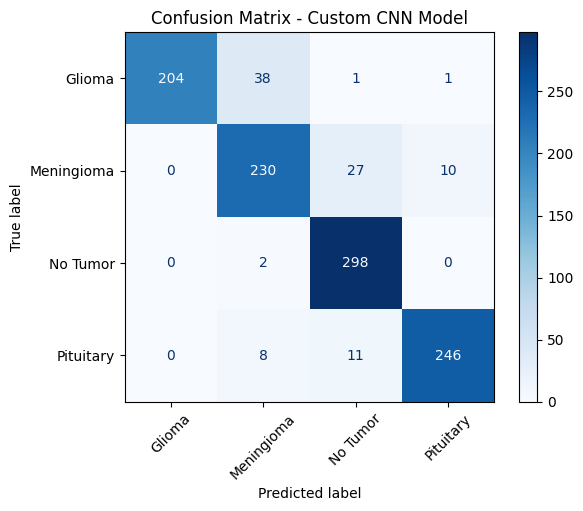

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Define your class labels
class_names = ["Glioma", "Meningioma", "No Tumor", "Pituitary"]

# Collect true and predicted labels
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    preds = tf.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds.numpy())

# Compute and plot confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

plt.figure(figsize=(6,6))
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix - Custom CNN Model")
plt.show()

In [25]:
# Path where you want to save the model (inside train directory)
model_save_path = '/Users/ayush/Desktop/Sem 2/ProjectInML1/split-dataset/training/my_model.h5'

# Save the complete model
model.save(model_save_path)

print(f"Model successfully saved at: {model_save_path}")

Model successfully saved at: /Users/ayush/Desktop/Sem 2/ProjectInML1/split-dataset/training/my_model.h5


In [26]:
from tensorflow.keras.models import load_model

model = load_model('/Users/ayush/Desktop/Sem 2/ProjectInML1/training/my_model.h5')

In [27]:
loss, acc = model.evaluate(test_ds)

print(f"Test Accuracy: {acc * 100:.2f}%")

68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9022 - loss: 0.2362
Test Accuracy: 89.22%


In [28]:
from sklearn.metrics import classification_report
import numpy as np

# Function to generate classification report
def print_classification_report(model, test_ds):
    true_labels = []
    pred_labels = []

    # Iterate over the test dataset to collect true labels and predictions
    for images, labels in test_ds:
        true_labels.extend(labels.numpy())  # True labels
        preds = model.predict(images, verbose = 0)  # Model predictions
        pred_labels.extend(np.argmax(preds, axis=1))  # Get the class with the highest probability

    true_labels = np.array(true_labels)
    pred_labels = np.array(pred_labels)

    # Generate classification report
    report = classification_report(true_labels, pred_labels)
    print(report)

# Print the classification report for your model
print_classification_report(model, test_ds)

              precision    recall  f1-score   support

           0       0.96      0.82      0.89       244
           1       0.80      0.83      0.81       267
           2       0.90      0.98      0.94       300
           3       0.92      0.92      0.92       265

    accuracy                           0.89      1076
   macro avg       0.90      0.89      0.89      1076
weighted avg       0.90      0.89      0.89      1076



2025-03-21 22:20:28.005112: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


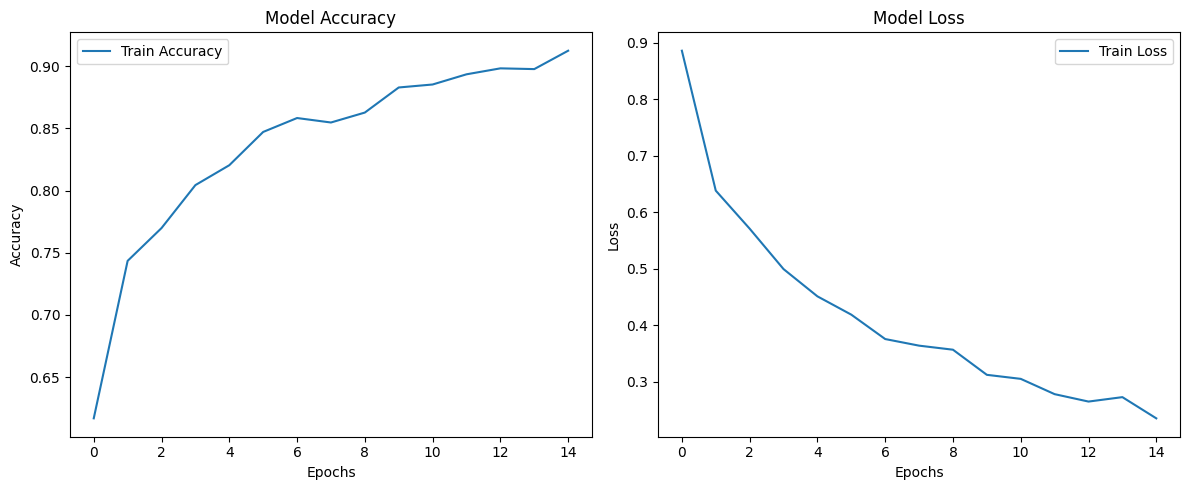

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

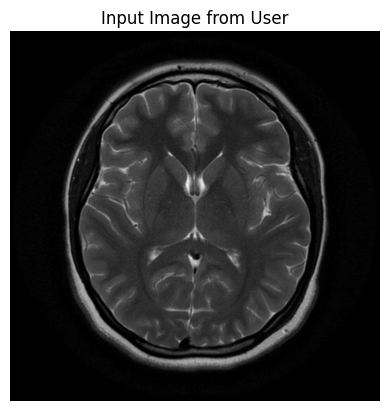

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Prediction Probabilities: [[0.1749319  0.17489025 0.47528762 0.17489022]]
Predicted Class Index: 2, Predicted Class Name: No Tumor


'No Tumor'

In [ ]:
import requests
import numpy as np
import tensorflow as tf
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

class_names = ["Glioma", "Meningioma", "No Tumor", "Pituitary"]

# Function to download an image from a URL
def download_image(image_url, target_size):
    try:
        response = requests.get(image_url)
        response.raise_for_status()

        # Open and convert to RGB
        image = Image.open(BytesIO(response.content)).convert("RGB")

        # Display the original image
        plt.imshow(image)
        plt.axis("off")
        plt.title("Input Image from User")
        plt.show()

        # Resize for model input
        image = image.resize(target_size)

        # Convert to NumPy and expand dimensions
        image_array = np.array(image)
        image_array = np.expand_dims(image_array, axis=0)

        return image_array
    except Exception as e:
        print(f"Error downloading or processing the image: {e}")
        return None

# Function to predict on an image
def predict_from_url(model, image_url, target_size):
    image_array = download_image(image_url, target_size)

    if image_array is not None:
        predictions = model.predict(image_array)
        probabilities = tf.nn.softmax(predictions).numpy()
        print("Prediction Probabilities:", probabilities)

        predicted_class = np.argmax(predictions, axis=1)[0]
        predicted_class_name = class_names[predicted_class]

        print(f"Predicted Class Index: {predicted_class}, Predicted Class Name: {predicted_class_name}")
        return predicted_class_name
    else:
        print("Prediction failed due to image download error.")

# Test image URL
target_size = (128, 128)
image_url = "https://prod-images-static.radiopaedia.org/images/13656005/bd937738ad6223a03f8aedcf4920a7_big_gallery.jpeg"

predict_from_url(model, image_url, target_size)

In [ ]:
class_names = ["Glioma", "Meningioma", "No Tumor", "Pituitary"]

# Function to download an image from a URL
def download_image(image_url, target_size):
    try:
        response = requests.get(image_url)
        response.raise_for_status()

        # Open the image and convert it to RGB
        image = Image.open(BytesIO(response.content)).convert("RGB")

        # Resize the image to match the model's input size
        image = image.resize(target_size)

        # Convert the image to a NumPy array
        image_array = np.array(image)

        # Add batch dimension for prediction
        image_array = np.expand_dims(image_array, axis=0)

        return image_array
    except Exception as e:
        print(f"Error downloading or processing the image: {e}")
        return None


# Function to predict on an image
def predict_from_url(model, image_url, target_size):
    # Download the image
    image_array = download_image(image_url, target_size)

    if image_array is not None:
        # Run the model prediction
        predictions = model.predict(image_array)

        # Apply softmax to logits to get probabilities
        probabilities = tf.nn.softmax(predictions).numpy()

        # Print the probabilities for each class
        print("Prediction Probabilities:", probabilities)

        # Assuming a classification model, get the class with highest probability
        predicted_class = np.argmax(predictions, axis=1)[0]

        # Get the class name from the model's class names
        predicted_class_name = class_names[predicted_class]

        print(f"Predicted Class Index: {predicted_class}, Predicted Class Name: {predicted_class_name}")
        return predicted_class_name
    else:
        print("Prediction failed due to image download error.")


target_size = (128, 128)
image_url = "https://prod-images-static.radiopaedia.org/images/13656005/bd937738ad6223a03f8aedcf4920a7_big_gallery.jpeg"

predict_from_url(model, image_url, target_size)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Prediction Probabilities: [[0.1749319  0.17489025 0.47528762 0.17489022]]
Predicted Class Index: 2, Predicted Class Name: No Tumor


'No Tumor'



____________



### ResNet50

In [29]:
resnet = ResNet50(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
resnet.trainable = False

In [30]:
modelResnet = Sequential([
    resnet,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

In [31]:
modelResnet.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [32]:
modelResnet.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 4, 4, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,500 (90.98 MB)

 Trainable params: 262,788 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [36]:
historyResnet = modelResnet.fit(
    train_ds,
    epochs=15
)

Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 49s 148ms/step - accuracy: 0.7342 - loss: 0.7696
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 47s 149ms/step - accuracy: 0.9101 - loss: 0.2435
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 46s 148ms/step - accuracy: 0.9290 - loss: 0.1778
Epoch 4/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 46s 146ms/step - accuracy: 0.9525 - loss: 0.1345
Epoch 5/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 46s 148ms/step - accuracy: 0.9592 - loss: 0.1067
Epoch 6/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 46s 146ms/step - accuracy: 0.9789 - loss: 0.0671
Epoch 7/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 48s 155ms/step - accuracy: 0.9844 - loss: 0.0525
Epoch 8/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 46s 146ms/step - accuracy: 0.9766 - loss: 0.0605
Epoch 9/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 45s 144ms/step - accuracy: 0.9812 - loss: 0.0514
Epoch 10/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 46s 146ms/step - accuracy: 0.9877 - loss: 0.0392
Epoch 11/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 46s 147ms/step - accuracy: 0.9888 - loss: 0.0324
Epoch 12/15
313/313

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

<Figure size 600x600 with 0 Axes>

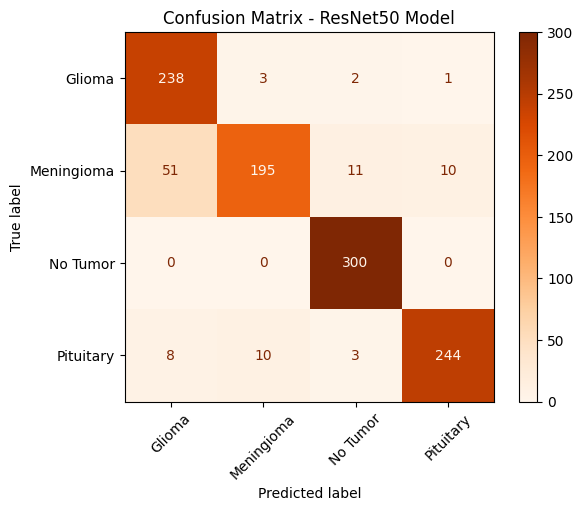

In [37]:
# Get true labels and predicted labels
y_true_resnet = []
y_pred_resnet = []

for images, labels in test_ds:
    preds = modelResnet.predict(images)
    preds = tf.argmax(preds, axis=1)

    y_true_resnet.extend(labels.numpy())
    y_pred_resnet.extend(preds.numpy())

# Compute confusion matrix
cm_resnet = confusion_matrix(y_true_resnet, y_pred_resnet)
disp_resnet = ConfusionMatrixDisplay(confusion_matrix=cm_resnet, display_labels=class_names)

# Plot
plt.figure(figsize=(6,6))
disp_resnet.plot(cmap='Oranges', xticks_rotation=45)
plt.title("Confusion Matrix - ResNet50 Model")
plt.show()

In [40]:
resnet_model_path = '/Users/ayush/Desktop/Sem 2/ProjectInML1/training/resnet50_model.h5'
modelResnet.save(resnet_model_path)

print(f"✅ ResNet50 model saved at: {resnet_model_path}")

✅ ResNet50 model saved at: /Users/ayush/Desktop/Sem 2/ProjectInML1/training/resnet50_model.h5


In [41]:
from tensorflow.keras.models import load_model

loaded_model = load_model('/Users/ayush/Desktop/Sem 2/ProjectInML1/training/resnet50_model.h5')

In [42]:
loss, acc = modelResnet.evaluate(test_ds)

print(f"Test Accuracy: {acc * 100:.2f}%")

68/68 ━━━━━━━━━━━━━━━━━━━━ 12s 170ms/step - accuracy: 0.9092 - loss: 0.2936
Test Accuracy: 90.80%


In [ ]:
from sklearn.metrics import classification_report
import numpy as np

# Function to generate classification report
def print_classification_report(model, test_ds):
    true_labels = []
    pred_labels = []

    # Iterate over the test dataset to collect true labels and predictions
    for images, labels in test_ds:
        true_labels.extend(labels.numpy())  # True labels
        preds = model.predict(images, verbose = 0)  # Model predictions
        pred_labels.extend(np.argmax(preds, axis=1))  # Get the class with the highest probability

    true_labels = np.array(true_labels)
    pred_labels = np.array(pred_labels)

    # Generate classification report
    report = classification_report(true_labels, pred_labels)
    print(report)

# Print the classification report for your model
print_classification_report(modelResnet, test_ds)


              precision    recall  f1-score   support

           0       0.97      0.88      0.92       244
           1       0.88      0.94      0.91       267
           2       0.97      1.00      0.98       300
           3       0.97      0.97      0.97       265

    accuracy                           0.95      1076
   macro avg       0.95      0.95      0.95      1076
weighted avg       0.95      0.95      0.95      1076



2025-03-21 21:48:34.465624: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


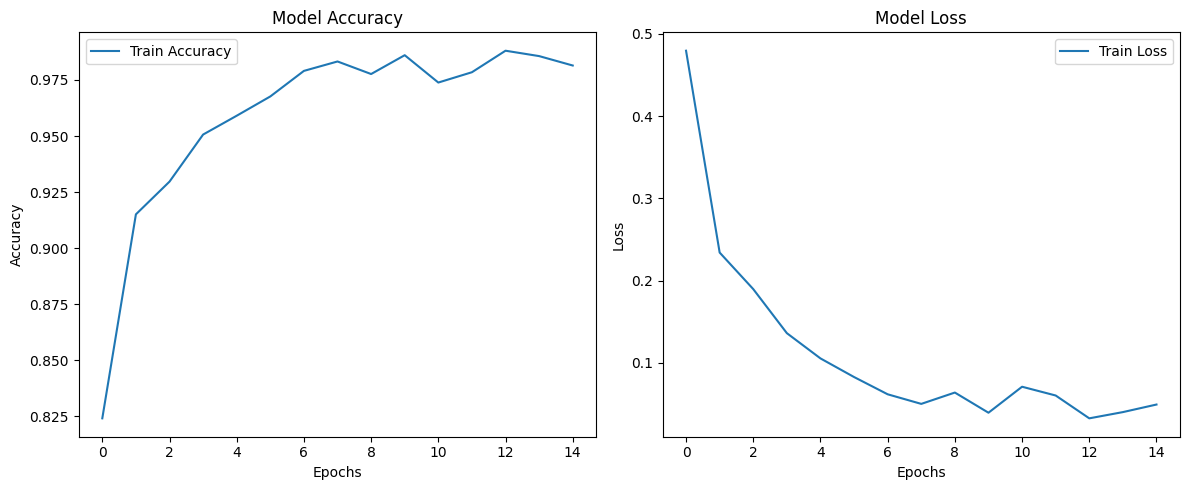

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(historyResnet.history['accuracy'], label='Train Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(historyResnet.history['loss'], label='Train Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

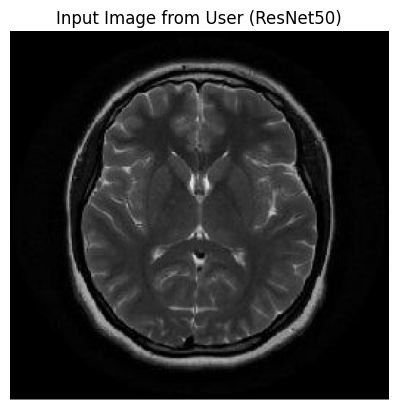

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
Prediction Probabilities: [[8.63459349e-01 1.81987118e-02 1.18341915e-01 6.09657524e-09]]
Predicted Class Index: 0, Predicted Class Name: Glioma


'Glioma'

In [47]:
import requests
import numpy as np
import tensorflow as tf
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

# Your class labels (same as before)
class_names = ["Glioma", "Meningioma", "No Tumor", "Pituitary"]

# Function to download and preprocess image from a URL
def download_image(image_url, target_size):
    try:
        response = requests.get(image_url)
        response.raise_for_status()

        # Open and convert image to RGB
        image = Image.open(BytesIO(response.content)).convert("RGB")

        # Show the original image
        plt.imshow(image)
        plt.axis("off")
        plt.title("Input Image from User (ResNet50)")
        plt.show()

        # Resize and convert to numpy
        image = image.resize(target_size)
        image_array = np.array(image)

        # Normalize (rescale to 0–1 range)
        image_array = image_array.astype("float32") / 255.0

        # Expand dimensions to match model input shape: (1, 128, 128, 3)
        image_array = np.expand_dims(image_array, axis=0)

        return image_array
    except Exception as e:
        print(f"Error downloading or processing the image: {e}")
        return None

# Function to predict using ResNet50 model
def predict_with_resnet(model, image_url, target_size):
    image_array = download_image(image_url, target_size)

    if image_array is not None:
        predictions = model.predict(image_array)
        predicted_class = np.argmax(predictions, axis=1)[0]
        predicted_class_name = class_names[predicted_class]

        print(f"Prediction Probabilities: {predictions}")
        print(f"Predicted Class Index: {predicted_class}, Predicted Class Name: {predicted_class_name}")
        return predicted_class_name
    else:
        print("Prediction failed due to image error.")

# 🔍 Test with an image URL
target_size = (128, 128)
image_url = "https://miro.medium.com/v2/resize:fit:257/1*BGxLxoHd8MG9m8gesYIprw.jpeg"

# Call the ResNet50 prediction function
predict_with_resnet(modelResnet, image_url, target_size)

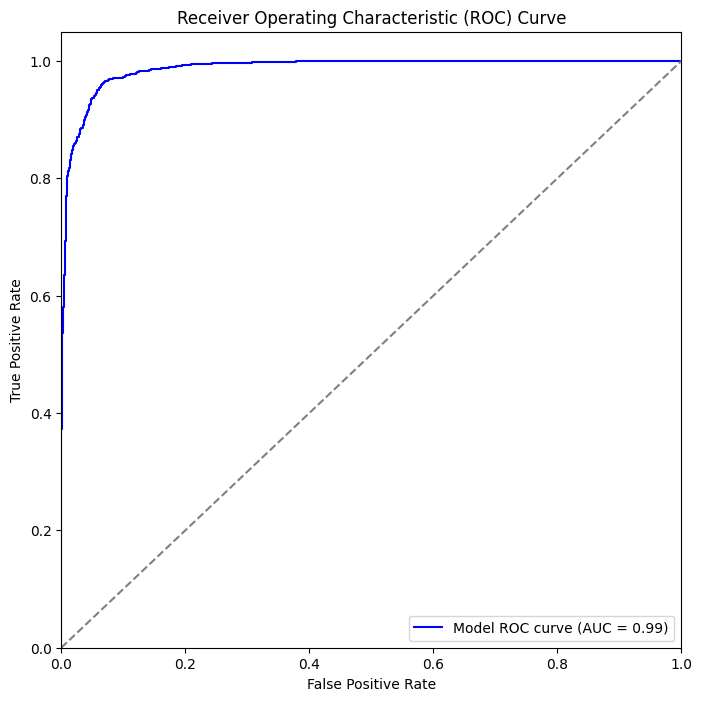

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from tensorflow.keras.utils import to_categorical

# Function to compute ROC and AUC
def plot_roc_curve(model, test_ds, num_classes):
    # Get true labels and predicted probabilities
    true_labels = []
    pred_probs = []

    for images, labels in test_ds:
        true_labels.extend(labels.numpy())  # True labels (from the dataset)
        preds = model.predict(images, verbose=0)  # Model predictions
        pred_probs.extend(preds)  # Predicted probabilities for each class

    # Convert to numpy arrays
    true_labels = np.array(true_labels)
    pred_probs = np.array(pred_probs)

    # Binarize the true labels (multi-class to one-hot encoding)
    true_labels_one_hot = to_categorical(true_labels, num_classes)

    # Compute ROC curve and AUC for each class
    fpr, tpr, thresholds = roc_curve(true_labels_one_hot.ravel(), pred_probs.ravel())
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve
    plt.figure(figsize=(8, 8))
    plt.plot(fpr, tpr, color='b', label=f'Model ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line (chance level)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc='lower right')
    plt.show()

# Plot ROC curve for your model
plot_roc_curve(model, test_ds, num_classes)


### Conclusion

The CNN and ResNet50 models were used for classifying brain tumors into four categories: glioma, meningioma, notumor, and pituitary. The CNN model achieved an accuracy of 91.07%, while ResNet50 outperformed it with an accuracy of 93.79%. Both models demonstrated strong performance, with ResNet50 achieving higher precision and recall across all tumor types. The models proved effective in detecting and classifying brain tumors, with potential for further improvements through optimizations.

# VGG16

In [68]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image_dataset_from_directory
from sklearn.utils import class_weight
from tensorflow.keras.applications.vgg16 import preprocess_input
import numpy as np
import os

In [66]:
# Paths
train_path = "/Users/ayush/Desktop/Sem 2/ProjectInML1/split-dataset/train"
test_path = "/Users/ayush/Desktop/Sem 2/ProjectInML1/split-dataset/test"

# Load datasets
image_size = (224, 224)
batch_size = 16

train_ds = image_dataset_from_directory(train_path, image_size=image_size, batch_size=batch_size, shuffle=True)
test_ds = image_dataset_from_directory(test_path, image_size=image_size, batch_size=batch_size, shuffle=False)

class_names = train_ds.class_names
num_classes = len(class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

# Compute class weights
all_labels = []
for _, labels in train_ds.unbatch():
    all_labels.append(labels.numpy())
class_weights = class_weight.compute_class_weight(class_weight='balanced', classes=np.unique(all_labels), y=all_labels)
class_weights_dict = dict(enumerate(class_weights))

Found 5005 files belonging to 4 classes.
Found 1076 files belonging to 4 classes.


In [53]:
all_labels = []
for _, labels in train_ds.unbatch():
    all_labels.append(labels.numpy())

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(all_labels),
    y=all_labels
)
class_weights_dict = dict(enumerate(class_weights))

In [69]:
# Data augmentation (simplified for medical images)
data_augmentation = tf.keras.Sequential([
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.05, 0.05)
])

# VGG16 base with ALL layers trainable
vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
vgg_base.trainable = True  # Fine-tune entire base model

# Define model
modelVGG = models.Sequential([
    data_augmentation,
    layers.Lambda(preprocess_input),  # ✅ Use correct VGG preprocessing
    vgg_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

# Compile
modelVGG.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),  # Smaller LR for fine-tuning
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

modelVGG.build((None, 224, 224, 3))
modelVGG.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_8 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,868 (56.38 MB)

 Trainable params: 14,780,868 (56.38 MB)

 Non-trainable params: 0 (0.00 B)

In [72]:
# Step 1: Freeze most of VGG16, fine-tune only top 8 layers
vgg_base.trainable = False
for layer in vgg_base.layers[-8:]:
    layer.trainable = True

# Step 2: Reduce image size to speed up data loading and GPU use
image_size = (160, 160)  # Instead of 224x224

In [74]:
historyVGG = modelVGG.fit(
    train_ds,
    epochs=10,
    validation_data=test_ds,
    class_weight=class_weights_dict,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
        tf.keras.callbacks.ModelCheckpoint("best_vgg16.keras", save_best_only=True)
    ]
)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1864s 6s/step - accuracy: 0.7311 - loss: 0.6662 - val_accuracy: 0.7602 - val_loss: 0.6119
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1542s 5s/step - accuracy: 0.8490 - loss: 0.4250 - val_accuracy: 0.8522 - val_loss: 0.4837
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1535s 5s/step - accuracy: 0.8514 - loss: 0.4356 - val_accuracy: 0.8773 - val_loss: 0.3550
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1544s 5s/step - accuracy: 0.8412 - loss: 0.4550 - val_accuracy: 0.8745 - val_loss: 0.3230
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1537s 5s/step - accuracy: 0.8878 - loss: 0.3149 - val_accuracy: 0.8885 - val_loss: 0.2865
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1538s 5s/step - accuracy: 0.9100 - loss: 0.2464 - val_accuracy: 0.9006 - val_loss: 0.2619
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1532s 5s/step - accuracy: 0.9204 - loss: 0.2270 - val_accuracy: 0.9359 - val_loss: 0.1616
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1534s 5s/step - accuracy: 0.9522 - loss: 0.1566 - 

In [75]:
modelVGG.save("vgg16_finetuned_epoch10_acc93.keras")

In [78]:
from tensorflow.keras.models import load_model

try:
    model = load_model("vgg16_finetuned_epoch10_acc93.keras")
    print("✅ Model loaded successfully!")
except Exception as e:
    print(f"❌ Failed to load model: {e}")

❌ Failed to load model: <class 'keras.src.models.sequential.Sequential'> could not be deserialized properly. Please ensure that components that are Python object instances (layers, models, etc.) returned by `get_config()` are explicitly deserialized in the model's `from_config()` method.

config={'module': 'keras', 'class_name': 'Sequential', 'config': {'name': 'sequential_9', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None, 'shared_object_id': 6266162576}, 'layers': [{'module': 'keras.layers', 'class_name': 'InputLayer', 'config': {'batch_shape': [None, 224, 224, 3], 'dtype': 'float32', 'sparse': False, 'name': 'input_layer_11'}, 'registered_name': None}, {'module': 'keras', 'class_name': 'Sequential', 'config': {'name': 'sequential_8', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None, 'shared_object_id': 6266162576}, 'l

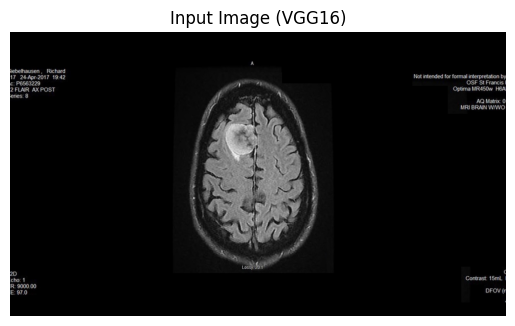

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step
Prediction Probabilities: [[0.25038627 0.24765992 0.25153366 0.25042018]]
Predicted Class: notumor


'notumor'

In [65]:
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

# Function to load and preprocess image from URL
def download_image(image_url, target_size):
    try:
        response = requests.get(image_url)
        response.raise_for_status()
        image = Image.open(BytesIO(response.content)).convert("RGB")
        plt.imshow(image)
        plt.axis("off")
        plt.title("Input Image (VGG16)")
        plt.show()

        image = image.resize(target_size)
        image_array = np.array(image).astype("float32") / 255.0
        image_array = np.expand_dims(image_array, axis=0)
        return image_array
    except Exception as e:
        print(f"Error downloading image: {e}")
        return None

# Predict function
def predict_with_vgg(model, image_url, target_size):
    image_array = download_image(image_url, target_size)
    if image_array is not None:
        predictions = model.predict(image_array)
        predicted_class = np.argmax(predictions, axis=1)[0]
        predicted_class_name = class_names[predicted_class]

        print(f"Prediction Probabilities: {predictions}")
        print(f"Predicted Class: {predicted_class_name}")
        return predicted_class_name
    else:
        print("Prediction failed.")

# 🔍 Example usage
image_url = "https://www.osfhealthcare.org/blog/wp-content/uploads/2019/10/brain-tumor-ini-ft3.jpg"
predict_with_vgg(modelVGG, image_url, (224, 224))

## VGG16 NO Lambda

In [79]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image_dataset_from_directory
from sklearn.utils import class_weight
import numpy as np
import os

In [80]:
# Paths
train_path = "/Users/ayush/Desktop/Sem 2/ProjectInML1/split-dataset/train"
test_path = "/Users/ayush/Desktop/Sem 2/ProjectInML1/split-dataset/test"

# Image size and batch
image_size = (160, 160)  # Updated to 160x160 for faster training
batch_size = 16

# Load datasets
train_ds = image_dataset_from_directory(train_path, image_size=image_size, batch_size=batch_size, shuffle=True)
test_ds = image_dataset_from_directory(test_path, image_size=image_size, batch_size=batch_size, shuffle=False)

class_names = train_ds.class_names
num_classes = len(class_names)

AUTOTUNE = tf.data.AUTOTUNE

Found 5005 files belonging to 4 classes.
Found 1076 files belonging to 4 classes.


In [81]:
# Preprocess images using map function instead of Lambda layer
def preprocess(image, label):
    return tf.keras.applications.vgg16.preprocess_input(image), label

train_ds = train_ds.map(preprocess).cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.map(preprocess).cache().prefetch(buffer_size=AUTOTUNE)

# Compute class weights to address class imbalance
all_labels = []
for _, labels in train_ds.unbatch():
    all_labels.append(labels.numpy())

class_weights = class_weight.compute_class_weight(class_weight='balanced', classes=np.unique(all_labels), y=all_labels)
class_weights_dict = dict(enumerate(class_weights))

# Data augmentation (simplified for medical images)
data_augmentation = tf.keras.Sequential([
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.05, 0.05)
])

2025-03-30 23:32:28.475783: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [84]:
# VGG16 base model with all layers trainable
vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(160, 160, 3))
vgg_base.trainable = False  # Freeze base VGG16 layers for initial training

# Define the full model
modelVGG = models.Sequential([
    data_augmentation,
    vgg_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

vgg_base.trainable = True
for layer in vgg_base.layers[:-8]:
    layer.trainable = False
    
# Compile the model
modelVGG.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [85]:
# Show model summary
modelVGG.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_10 (Sequential)      │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 5, 5, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 12,979,200 (49.51 MB)

 Non-trainable params: 1,735,488 (6.62 MB)

In [88]:
import tensorflow as tf
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image_dataset_from_directory
from sklearn.utils import class_weight
import numpy as np
import os

# Paths
train_path = "/Users/ayush/Desktop/Sem 2/ProjectInML1/split-dataset/train"
val_path = "/Users/ayush/Desktop/Sem 2/ProjectInML1/split-dataset/val"
test_path = "/Users/ayush/Desktop/Sem 2/ProjectInML1/split-dataset/test"

# Parameters
image_size = (160, 160)
batch_size = 16

# Load and preprocess datasets
def preprocess(image, label):
    return preprocess_input(image), label

train_ds = image_dataset_from_directory(train_path, image_size=image_size, batch_size=batch_size)
val_ds = image_dataset_from_directory(val_path, image_size=image_size, batch_size=batch_size)
test_ds = image_dataset_from_directory(test_path, image_size=image_size, batch_size=batch_size, shuffle=False)

class_names = train_ds.class_names
num_classes = len(class_names)

# Apply preprocessing
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.map(preprocess).cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.map(preprocess).cache().prefetch(AUTOTUNE)
test_ds = test_ds.map(preprocess).cache().prefetch(AUTOTUNE)

# Class weights
all_labels = [label.numpy() for _, label in train_ds.unbatch()]
weights = class_weight.compute_class_weight('balanced', classes=np.unique(all_labels), y=all_labels)
class_weights_dict = dict(enumerate(weights))

# Data augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.05, 0.05)
])

# Load and partially fine-tune VGG16
vgg_base = VGG16(include_top=False, weights='imagenet', input_shape=(160, 160, 3))
vgg_base.trainable = True
for layer in vgg_base.layers[:-8]:
    layer.trainable = False  # Fine-tune last 8 layers

# Define model
modelVGG = models.Sequential([
    data_augmentation,
    vgg_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

# Compile
modelVGG.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train (this is necessary since Lambda issue corrupted previous model)
historyVGG = modelVGG.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights_dict,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
        tf.keras.callbacks.ModelCheckpoint("vgg16_clean.keras", save_best_only=True)
    ]
)

# Save final model
modelVGG.save("vgg16_final_model.keras")

Found 5005 files belonging to 4 classes.
Found 1072 files belonging to 4 classes.
Found 1076 files belonging to 4 classes.
Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 546s 2s/step - accuracy: 0.4908 - loss: 1.3884 - val_accuracy: 0.8172 - val_loss: 0.6664
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 459s 1s/step - accuracy: 0.7599 - loss: 0.6291 - val_accuracy: 0.8993 - val_loss: 0.4379
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 468s 1s/step - accuracy: 0.8646 - loss: 0.3943 - val_accuracy: 0.9067 - val_loss: 0.5382
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 452s 1s/step - accuracy: 0.9246 - loss: 0.2395 - val_accuracy: 0.9076 - val_loss: 0.3771
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 451s 1s/step - accuracy: 0.9372 - loss: 0.1906 - val_accuracy: 0.9179 - val_loss: 0.2543
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 448s 1s/step - accuracy: 0.9577 - loss: 0.1180 - val_accuracy: 0.9356 - val_loss: 0.2108
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 451s 1s/step - accuracy: 0.9583 - loss: 0.1438 - val_accuracy: 

In [104]:
from tensorflow.keras.models import load_model

model = load_model("vgg16_clean.keras")
loss, acc = model.evaluate(test_ds)
print(f" Test Accuracy: {acc * 100:.2f}%")

68/68 ━━━━━━━━━━━━━━━━━━━━ 46s 663ms/step - accuracy: 0.9384 - loss: 0.1897
 Test Accuracy: 96.19%


In [106]:
import requests
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from io import BytesIO
from tensorflow.keras.applications.vgg16 import preprocess_input

# Assuming your model is already loaded as `model`
# Also assuming class_names is defined: ["Glioma", "Meningioma", "No Tumor", "Pituitary"]

def predict_from_url(model, image_url, target_size=(160, 160), class_names=None):
    try:
        response = requests.get(image_url)
        image = Image.open(BytesIO(response.content)).convert("RGB")

        # Display the image
        plt.imshow(image)
        plt.axis("off")
        plt.title("Input Image")
        plt.show()

        # Preprocess image
        image = image.resize(target_size)
        img_array = np.array(image).astype("float32")
        img_array = preprocess_input(img_array)
        img_array = np.expand_dims(img_array, axis=0)

        # Predict
        preds = model.predict(img_array)
        class_idx = np.argmax(preds)
        confidence = np.max(preds)

        if class_names:
            print(f" Prediction: {class_names[class_idx]} ({confidence * 100:.2f}%)")
        else:
            print(f"Class Index: {class_idx}, Confidence: {confidence * 100:.2f}%")

    except Exception as e:
        print(" Error:", e)

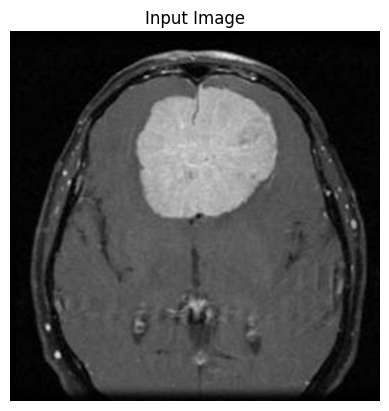

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
 Prediction: meningioma (100.00%)


In [107]:
predict_from_url(model, "https://prod-images-static.radiopaedia.org/images/8337017/dd86e8296503e5713851c6908df2bd_big_gallery.jpg", class_names=class_names)

In [108]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import seaborn as sns
import pandas as pd

def evaluate_model(model, test_ds, class_names):
    y_true = []
    y_pred = []

    for images, labels in test_ds:
        preds = model.predict(images)
        y_true.extend(labels.numpy())
        y_pred.extend(np.argmax(preds, axis=1))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    plt.figure(figsize=(6,6))
    disp.plot(cmap='Blues', xticks_rotation=45)
    plt.title("Confusion Matrix")
    plt.show()

    # Classification Report
    print(" Classification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 855ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 686ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 680ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 666ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 663ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 671ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 660ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 659ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 660ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 660ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 660ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 664ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 661ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 660ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 662ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 658ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 660ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 657ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 662ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 661ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 661ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 663ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 661ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 659ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 665ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

<Figure size 600x600 with 0 Axes>

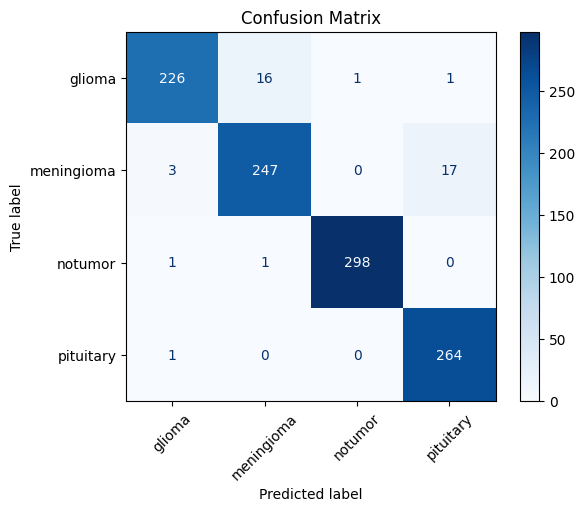

 Classification Report:
              precision    recall  f1-score   support

      glioma       0.98      0.93      0.95       244
  meningioma       0.94      0.93      0.93       267
     notumor       1.00      0.99      0.99       300
   pituitary       0.94      1.00      0.97       265

    accuracy                           0.96      1076
   macro avg       0.96      0.96      0.96      1076
weighted avg       0.96      0.96      0.96      1076



In [109]:
evaluate_model(model, test_ds, class_names)

In [113]:
from tensorflow.keras.models import load_model

# Load the model saved in .keras format
model = load_model("vgg16_final_model.keras")

# Save it in .h5 format
model.save("vgg16_final_model.h5")

print(" Model converted to H5 format!")

 Model converted to H5 format!
